### Limpieza y Preparación de Datos del Mundo Real


En este proyecto se aplican las habilidades adquiridas a lo largo del curso para recopilar, evaluar y limpiar datos del mundo real utilizando dos conjuntos de datos seleccionados.
Durante el desarrollo del proyecto, se extraerán y cargarán los datos, se evaluará su calidad y estructura tanto de forma programática como visual, y se implementará una estrategia de limpieza adecuada. Posteriormente, los datos limpiados se almacenarán en un repositorio local de datos, se combinarán ambos conjuntos y se responderá a una pregunta de investigación utilizando la información resultante.
A lo largo de todo el proceso, se espera que se lleven a cabo las siguientes acciones:

Explicar de forma clara las decisiones tomadas en relación con los métodos de recopilación, evaluación, limpieza, almacenamiento y análisis de los datos.
Incluir comentarios en el código para mejorar su legibilidad y facilitar su comprensión.
Instalar previamente los paquetes necesarios antes de comenzar el proyecto.

In [1]:
!python -m pip install kaggle==1.6.12

Defaulting to user installation because normal site-packages is not writeable


In [2]:
!pip install --target=/workspace ucimlrepo numpy==1.24.3

  Using cached ucimlrepo-0.0.7-py3-none-any.whl (8.0 kB)
  Using cached numpy-1.24.3-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (17.3 MB)
  Using cached pandas-2.3.3-cp310-cp310-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (12.8 MB)
  Using cached certifi-2026.2.25-py3-none-any.whl (153 kB)
  Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl (229 kB)
  Using cached tzdata-2026.1-py2.py3-none-any.whl (348 kB)
  Using cached pytz-2026.1.post1-py2.py3-none-any.whl (510 kB)
  Using cached six-1.17.0-py2.py3-none-any.whl (11 kB)


**Note:** Restart the kernel to use updated package(s).

## 1. Recolección de datos
En esta sección se recopilan los datos utilizando al menos dos métodos diferentes de recolección, con el objetivo de trabajar con conjuntos de datos reales y variados. Para ello, se seleccionan dos fuentes de datos y se explican los métodos empleados para su obtención.
Los datos serán extraídos, cargados y preparados para su posterior análisis y combinación. Se utilizarán al menos dos tipos distintos de métodos de recolección de datos, tales como la descarga manual de archivos, la descarga programática, el acceso a APIs u otros métodos disponibles. Esta diversidad permite practicar distintas técnicas de adquisición de datos y comprender mejor las particularidades de cada fuente.

### 1.1 Declaración del problema
El objetivo de este proyecto es analizar la relación entre el tamaño de la población de los países y los niveles de contaminación del aire medidos mediante el indicador PM2.5. Para ello, se utilizan dos conjuntos de datos reales: uno que contiene información sobre la población mundial por países a lo largo del tiempo y otro que recoge los niveles de contaminación del aire por país según el índice IQAir.
A través de la recopilación, evaluación, limpieza y combinación de ambos conjuntos de datos, se busca determinar si los países con mayor población tienden a presentar niveles más altos de contaminación del aire en el año 2021.

### 1.2 Recolección y descripción de los conjuntos de datos
En esta sección se describen los conjuntos de datos seleccionados, los métodos utilizados para su recolección y las variables principales que contienen. Ambos conjuntos de datos cumplen los requisitos del proyecto, ya que contienen más de dos variables y un número suficiente de observaciones para realizar un análisis significativo.

In [3]:
import os
os.getcwd()

'/workspace'

#### Dataset 1: Población mundial por países (1960–2021)

Tipo: Archivo CSV
Método de recolección: Descarga manual desde una plataforma de datos abierta (Kaggle).

Este conjunto de datos fue seleccionado porque proporciona información histórica detallada sobre la población de países de todo el mundo durante un largo período de tiempo (desde 1960 hasta 2021). Esto lo convierte en una fuente adecuada para realizar comparaciones demográficas entre países y seleccionar un año específico para el análisis.
Variables principales:

Country Name: Nombre del país (variable clave para la combinación de datasets).
Country Code: Código ISO del país.
1960–2021: Población total del país para cada año, almacenada en columnas separadas.

El conjunto de datos contiene más de 260 observaciones correspondientes a países y regiones, y más de 60 variables relacionadas con la población a lo largo del tiempo.

In [4]:
# Ver estructura en tu directorio actual
!ls -la


total 1108
drwxr-xr-x 23 student student   4096 Apr  7 06:22  .
drwxr-xr-x  1 root    root      4096 Apr  7 06:12  ..
drwxr-xr-x  2 student student   4096 Apr  7 06:12  .ipynb_checkpoints
-rw-r--r--  1 student student 257383 Apr  7 06:22  Data_Wrangling_Project_Starter.ipynb
-rw-r--r--  1 student student 141563 Apr  6 10:36  World-population-by-countries-dataset.csv
drwxr-xr-x  2 student student   4096 Apr  7 06:12  __pycache__
-rw-r--r--  1 student student 590482 Apr  6 10:36 'air quality index (by cities).csv'
-rw-r--r--  1 student student   4771 Apr  6 10:36 'air quality index to countries.csv'
drwxr-xr-x  2 student student   4096 Apr  7 06:12  bin
drwxr-xr-x  3 student student   4096 Apr  7 06:12  certifi
drwxr-xr-x  3 student student   4096 Apr  7 06:12  certifi-2026.2.25.dist-info
drwxr-xr-x  5 student student   4096 Apr  7 06:12  data
drwxr-xr-x  6 student student   4096 Apr  7 06:12  dateutil
drwxr-xr-x 21 student student   4096 Apr  7 06:12  numpy
drwxr-xr-x  2 student student

In [5]:
# Ver si existe data/
!ls -la data/raw


total 736
drwxr-xr-x 2 student student   4096 Apr  7 06:12  .
drwxr-xr-x 5 student student   4096 Apr  7 06:12  ..
-rw-r--r-- 1 student student 141563 Apr  6 10:37  World-population-by-countries-dataset.csv
-rw-r--r-- 1 student student 590482 Apr  6 10:37 'air quality index (by cities).csv'
-rw-r--r-- 1 student student   4771 Apr  6 10:37 'air quality index to countries.csv'


In [7]:
!find . -maxdepth 3 -type f \( -name "*.csv" -o -name "*.zip" \) | head -n 50

./air quality index (by cities).csv
./World-population-by-countries-dataset.csv
./data/raw/air quality index (by cities).csv
./data/raw/World-population-by-countries-dataset.csv
./data/raw/air quality index to countries.csv
./data/clean/population_air_quality_clean.csv
./data/clean/population_air_quality_2021_clean.csv
./air quality index to countries.csv


In [120]:
import glob
import pandas as pd

csv_files = glob.glob("data/raw/*.csv")
csv_files

['data/raw/air quality index (by cities).csv',
 'data/raw/World-population-by-countries-dataset.csv',
 'data/raw/air quality index to countries.csv']

In [121]:


population_path = "data/raw/World-population-by-countries-dataset.csv"

df_population = pd.read_csv(
    population_path,
    sep=";",
    engine="python"
)

# Quitar columna basura si existe
df_population = df_population.loc[:, ~df_population.columns.str.contains("^Unnamed")]

df_population.head(), df_population.shape


(                  Country Name Country Code       1960         1961  \
 0                        Aruba          ABW      54208      55434.0   
 1  Africa Eastern and Southern          AFE  130836765  134159786.0   
 2                  Afghanistan          AFG    8996967    9169406.0   
 3   Africa Western and Central          AFW   96396419   98407221.0   
 4                       Angola          AGO    5454938    5531451.0   
 
           1962         1963         1964         1965         1966  \
 0      56234.0      56699.0      57029.0      57357.0      57702.0   
 1  137614644.0  141202036.0  144920186.0  148769974.0  152752671.0   
 2    9351442.0    9543200.0    9744772.0    9956318.0   10174840.0   
 3  100506960.0  102691339.0  104953470.0  107289875.0  109701811.0   
 4    5608499.0    5679409.0    5734995.0    5770573.0    5781305.0   
 
           1967  ...         2012         2013         2014         2015  \
 0      58044.0  ...     102565.0     103165.0     103776.0   

#### Dataset 2: Índice de calidad del aire por países (IQAir – PM2.5)

Tipo: Archivos CSV
Método de recolección: Descarga manual desde Kaggle (dataset de IQAir).

Este conjunto de datos fue elegido porque proporciona información actualizada sobre la contaminación del aire a nivel de país, utilizando el indicador PM2.5, que es ampliamente empleado para evaluar la calidad del aire y sus efectos en la salud. El dataset permite comparar los niveles de contaminación entre diferentes países y años.
Variables principales:

Country/Region: Nombre del país (utilizado como clave para la combinación tras su estandarización).
2018–2021: Valores anuales de PM2.5, almacenados en columnas separadas (lo que representa un problema de orden o tidiness).
Population: Valor de población proporcionado por el dataset de IQAir (utilizado para comparación, pero no como fuente principal de población).

El conjunto de datos contiene más de 100 países y cumple con el requisito mínimo de tamaño y número de variables necesarios para el análisis.

In [122]:


air_cities_path = "data/raw/air quality index (by cities).csv"

df_air_cities = pd.read_csv(
    air_cities_path,
    sep=";",            
    engine="python",    
    on_bad_lines="warn" # avisa si hay alguna línea rara, pero no rompe
)

df_air_cities.head(), df_air_cities.shape

(   Rank              City   2021 JAN(2021) FEB(2021) MAR(2021) APR(2021)  \
 0     1    Bhiwadi, India  106.2     145.8     129.8     120.2     125.7   
 1     2  Ghaziabad, India  102.0     199.9     172.2      97.8      86.3   
 2     3      Hotan, China  101.5         -         -       158      91.1   
 3     4      Delhi, India   96.4     183.7     142.2      80.5      72.9   
 4     5    Jaunpur, India   95.3     182.2     143.5        91        70   
 
   MAY(2021) JUN(2021) JUL(2021) AUG(2021) SEP(2021) OCT(2021) NOV(2021)  \
 0      86.5      95.9      55.6      55.4      37.1      91.1     188.6   
 1      52.9      47.2      35.3      37.6      30.8      89.7     218.3   
 2     167.4      57.4      70.9      93.2      79.3     126.1     111.5   
 3      47.4      47.1      35.6      36.9      30.2      73.7     224.1   
 4      51.1      40.7      33.5      34.2      36.8      75.7       196   
 
   DEC(2021)   2020   2019   2018   2017  
 0     136.6   95.5   83.4  125.4  

In [11]:
df_air_cities.info()
df_air_cities.isnull().sum().sort_values(ascending=False).head(10)
df_air_cities.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6475 entries, 0 to 6474
Data columns (total 19 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Rank       6475 non-null   int64  
 1   City       6475 non-null   object 
 2   2021       6475 non-null   float64
 3   JAN(2021)  6475 non-null   object 
 4   FEB(2021)  6475 non-null   object 
 5   MAR(2021)  6475 non-null   object 
 6   APR(2021)  6475 non-null   object 
 7   MAY(2021)  6475 non-null   object 
 8   JUN(2021)  6475 non-null   object 
 9   JUL(2021)  6475 non-null   object 
 10  AUG(2021)  6475 non-null   object 
 11  SEP(2021)  6475 non-null   object 
 12  OCT(2021)  6475 non-null   object 
 13  NOV(2021)  6475 non-null   object 
 14  DEC(2021)  6475 non-null   object 
 15  2020       6475 non-null   object 
 16  2019       6475 non-null   object 
 17  2018       6475 non-null   object 
 18  2017       6475 non-null   object 
dtypes: float64(1), int64(1), object(17)
memory usage

0

In [12]:
# Ver primeras 5 líneas
!head -n 5 "data/raw/air quality index (by cities).csv"

Optional data storing step: You may save your raw dataset files to the local data store before moving to the next step.

In [13]:
# Pasar de ; a ,
air_countries_path = "data/raw/air quality index to countries.csv"

df_air_countries = pd.read_csv(
    air_countries_path,
    sep=";",
    engine="python",
    on_bad_lines="warn"
)

df_air_countries.head(), df_air_countries.shape

(   Rank Country/Region  2021  2020  2019  2018     Population
 0     1     Bangladesh  76.9  77.1  83.3  97.1    164,689,383
 1     2           Chad  75.9     -     -     -     16,425,859
 2     3       Pakistan  66.8    59  65.8  74.3    220,892,331
 3     4     Tajikistan  59.4  30.9     -     -      9,537,642
 4     5          India  58.1  51.9  58.1  72.5  1,380,004,385,
 (118, 7))

In [14]:
df_air_countries.info()
df_air_countries.isnull().sum().sort_values(ascending=False).head(10)
df_air_countries.duplicated().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118 entries, 0 to 117
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Rank            118 non-null    int64  
 1   Country/Region  118 non-null    object 
 2   2021            118 non-null    float64
 3   2020            118 non-null    object 
 4   2019            118 non-null    object 
 5   2018            118 non-null    object 
 6   Population      118 non-null    object 
dtypes: float64(1), int64(1), object(5)
memory usage: 6.6+ KB


0

In [15]:
print(df_air_cities.columns)
print(df_air_countries.columns)

Index(['Rank', 'City', '2021', 'JAN(2021)', 'FEB(2021)', 'MAR(2021)',
       'APR(2021)', 'MAY(2021)', 'JUN(2021)', 'JUL(2021)', 'AUG(2021)',
       'SEP(2021)', 'OCT(2021)', 'NOV(2021)', 'DEC(2021)', '2020', '2019',
       '2018', '2017'],
      dtype='object')
Index(['Rank', 'Country/Region', '2021', '2020', '2019', '2018', 'Population'], dtype='object')


## 2. Evaluación de los datos (Assess data)
En esta sección se evalúan los conjuntos de datos en función de criterios de calidad de los datos y principios de orden o tidiness. El objetivo es identificar problemas que puedan afectar al análisis y que deban resolverse durante la fase de limpieza.
Se identifican dos problemas de calidad de datos y dos problemas de estructura (tidiness). Cada problema se evalúa tanto de forma visual como programática, y se justifica el método utilizado para su detección.

### Calidad de los datos
### Quality Issue 1: Valores faltantes en variables clave
Evaluación visual:
Mediante la inspección del resumen estadístico del dataset (describe(include="all").T) y la visualización de las primeras filas con head(), se observa que algunas columnas correspondientes a los valores anuales de PM2.5 (2018–2020) contienen el símbolo "-", lo que indica valores ausentes o no registrados.
Evaluación programática:
El uso de isnull().sum() después de convertir las columnas a formato numérico permite cuantificar los valores faltantes en cada una de las variables anuales.

Descripción del problema:
La presencia de valores faltantes en variables clave de contaminación puede afectar a la completitud del dataset y sesgar análisis descriptivos o comparaciones entre países si no se gestionan adecuadamente.
Justificación del método:
La combinación de describe() para una visión general y isnull().sum() para una medición precisa es adecuada para evaluar la completitud del dataset de manera sistemática y reproducible.

In [53]:
df_air_countries.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Rank,118.0,NaN,NaN,NaN,59.5,34.207699,1.0,30.25,59.5,88.75,118.0
Country/Region,118,118,Bangladesh,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021,118.0,NaN,NaN,NaN,21.027119,15.023336,3.8,10.725,16.75,25.9,76.9
2020,118,87,-,17,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019,118,82,-,27,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018,118,70,-,46,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Population,118,118,"164,689,383",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [54]:
(df_air_countries[["2018","2019","2020"]].eq("-")).sum()

2018    46
2019    27
2020    17
dtype: int64

Problema:
El conjunto de datos contiene valores faltantes en una o más columnas clave (por ejemplo, valores anuales de contaminación o población), lo que afecta a la completitud de los datos y puede sesgar los resúmenes estadísticos o las visualizaciones si no se gestionan adecuadamente.

Justificación:
El método describe(include="all").T proporciona un resumen visual rápido que ayuda a identificar distribuciones inesperadas o patrones de datos faltantes, mientras que isnull().sum() permite cuantificar de forma programática los valores faltantes por columna y confirmar el problema de completitud.

### Quality Issue 2: Tipos inválidos y valores no numéricos en columnas numéricas

In [92]:
# Visual inspection: check how numeric columns look in raw data
df_air_countries[["Country/Region", "2018", "2019", "2020", "2021", "Population"]].head(10)

,Country/Region,2018,2019,2020,2021,Population
0,Bangladesh,97.1,83.3,77.1,76.9,"164,689,383"
1,Chad,-,-,-,75.9,"16,425,859"
2,Pakistan,74.3,65.8,59,66.8,"220,892,331"
3,Tajikistan,-,-,30.9,59.4,"9,537,642"
4,India,72.5,58.1,51.9,58.1,"1,380,004,385"
5,Oman,-,-,44.4,53.9,"5,106,622"
6,Kyrgyzstan,-,33.2,43.5,50.8,"6,524,191"
7,Bahrain,59.8,46.8,39.7,49.8,"1,701,583"
8,Iraq,-,-,-,49.7,"40,222,503"
9,Nepal,54.1,44.5,39.2,46.0,"29,136,808"


In [93]:
df_air_countries.dtypes
df_air_countries.head(10)



,Rank,Country/Region,2021,2020,2019,2018,Population
0,1,Bangladesh,76.9,77.1,83.3,97.1,"164,689,383"
1,2,Chad,75.9,-,-,-,"16,425,859"
2,3,Pakistan,66.8,59,65.8,74.3,"220,892,331"
3,4,Tajikistan,59.4,30.9,-,-,"9,537,642"
4,5,India,58.1,51.9,58.1,72.5,"1,380,004,385"
5,6,Oman,53.9,44.4,-,-,"5,106,622"
6,7,Kyrgyzstan,50.8,43.5,33.2,-,"6,524,191"
7,8,Bahrain,49.8,39.7,46.8,59.8,"1,701,583"
8,9,Iraq,49.7,-,-,-,"40,222,503"
9,10,Nepal,46.0,39.2,44.5,54.1,"29,136,808"


In [94]:
# Programmatic inspection: check data types in raw dataset
cols_to_check = ["2018", "2019", "2020", "2021", "Population"]
df_air_countries[cols_to_check].dtypes
# Count placeholder missing values represented as "-"
(df_air_countries[["2018","2019","2020"]].eq("-")).sum()

2018    46
2019    27
2020    17
dtype: int64

Problema:
Las columnas que deberían contener valores numéricos (los valores correspondientes a los años 2018–2021 y la variable Population) pueden estar almacenadas como texto o contener caracteres no numéricos. Esto afecta a la validez de los datos, ya que impide realizar cálculos correctos, análisis de correlación y visualizaciones.

Justificación:
La inspección visual de algunas filas mediante head() permite detectar fácilmente problemas de formato (por ejemplo, cadenas de texto inesperadas). La comprobación de los tipos de datos con dtypes y el uso de pd.to_numeric(..., errors="coerce") confirman de forma programática los problemas de validez, al identificar columnas con tipos incorrectos y cuantificar los valores que no pueden convertirse a números.

### Tidiness Issue 1:

In [60]:
# Programmatic inspection: confirm that years are stored as separate columns
df_air_countries.columns

Index(['Rank', 'Country/Region', '2021', '2020', '2019', '2018', 'Population'], dtype='object')

In [100]:
# Visual inspection: the dataset is in wide format (years are columns)
df_air_countries.head()

,Rank,Country/Region,2021,2020,2019,2018,Population
0,1,Bangladesh,76.9,77.1,83.3,97.1,"164,689,383"
1,2,Chad,75.9,-,-,-,"16,425,859"
2,3,Pakistan,66.8,59,65.8,74.3,"220,892,331"
3,4,Tajikistan,59.4,30.9,-,-,"9,537,642"
4,5,India,58.1,51.9,58.1,72.5,"1,380,004,385"


Problema:
El conjunto de datos de países de IQAir no está organizado de forma ordenada (tidy), ya que los valores anuales de contaminación están almacenados en columnas separadas (2018, 2019, 2020, 2021) en lugar de concentrarse en una única columna denominada Year. Esto viola los principios de los datos ordenados (tidy data): una variable (el año) debe representarse en una sola columna, y cada observación país–año debería corresponder a una fila independiente.

Justificación:
El método df.head() es adecuado para confirmar visualmente la estructura en formato ancho y observar que los años aparecen como encabezados de columnas. La revisión de df.columns (y, opcionalmente, la detección de columnas numéricas que representan años) permite confirmar de forma programática el problema estructural e identificar qué columnas deben ser transformadas durante la fase de limpieza.

### Tidiness Issue 2: 

In [123]:


pop_path = "data/raw/World-population-by-countries-dataset.csv" 
# Pasamos de ; a ,
df_population = pd.read_csv(
    pop_path,
    sep=";",            
    engine="python"
)

print(df_population.shape)
print(df_population.columns[:5])
df_population.head()


(266, 65)
Index(['Country Name', 'Country Code', '1960', '1961', '1962'], dtype='object')


,Country Name,Country Code,1960,1961,1962,1963,1964,1965,1966,1967,...,2013,2014,2015,2016,2017,2018,2019,2020,2021,Unnamed: 64
0,Aruba,ABW,54208,55434.0,56234.0,56699.0,57029.0,57357.0,57702.0,58044.0,...,103165.0,103776.0,104339.0,104865.0,105361.0,105846.0,106310.0,106766.0,107195.0,NaN
1,Africa Eastern and Southern,AFE,130836765,134159786.0,137614644.0,141202036.0,144920186.0,148769974.0,152752671.0,156876454.0,...,562601578.0,578075373.0,593871847.0,609978946.0,626392880.0,643090131.0,660046272.0,677243299.0,694665117.0,NaN
2,Afghanistan,AFG,8996967,9169406.0,9351442.0,9543200.0,9744772.0,9956318.0,10174840.0,10399936.0,...,32269592.0,33370804.0,34413603.0,35383028.0,36296111.0,37171922.0,38041757.0,38928341.0,39835428.0,NaN
3,Africa Western and Central,AFW,96396419,98407221.0,100506960.0,102691339.0,104953470.0,107289875.0,109701811.0,112195950.0,...,380437896.0,390882979.0,401586651.0,412551299.0,423769930.0,435229381.0,446911598.0,458803476.0,470898870.0,NaN
4,Angola,AGO,5454938,5531451.0,5608499.0,5679409.0,5734995.0,5770573.0,5781305.0,5774440.0,...,26015786.0,26941773.0,27884380.0,28842482.0,29816769.0,30809787.0,31825299.0,32866268.0,33933611.0,NaN


In [96]:
print(df_population.columns)
#Borramos la ultima columna Unnamed: 64
df_population = df_population.loc[:, ~df_population.columns.str.contains("^Unnamed")]
print(df_population.columns[-5:])

Index(['Country Name', 'Country Code', '1960', '1961', '1962', '1963', '1964',
       '1965', '1966', '1967', '1968', '1969', '1970', '1971', '1972', '1973',
       '1974', '1975', '1976', '1977', '1978', '1979', '1980', '1981', '1982',
       '1983', '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991',
       '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000',
       '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009',
       '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018',
       '2019', '2020', '2021', 'Unnamed: 64'],
      dtype='object')
Index(['2017', '2018', '2019', '2020', '2021'], dtype='object')


In [97]:
df_population.head()
df_population = df_population.loc[:, ~df_population.columns.str.contains("^Unnamed")]
print(df_population.columns[-5:])

Index(['2017', '2018', '2019', '2020', '2021'], dtype='object')


In [98]:
# Visual inspection: both datasets describe countries, but store different variables in separate tables
df_population[['Country Name']].head(), df_air_countries[['Country/Region']].head()

(                  Country Name
 0                        Aruba
 1  Africa Eastern and Southern
 2                  Afghanistan
 3   Africa Western and Central
 4                       Angola,
   Country/Region
 0     Bangladesh
 1           Chad
 2       Pakistan
 3     Tajikistan
 4          India)

In [99]:
# Programmatic inspection: check shared merge key availability and overlap
pop_countries = set(df_population['Country Name'].dropna().unique())
air_countries = set(df_air_countries['Country/Region'].dropna().unique())

print("Unique countries in population dataset:", len(pop_countries))
print("Unique countries in IQAir countries dataset:", len(air_countries))

# overlap / intersection
common = pop_countries.intersection(air_countries)
print("Countries that match exactly (intersection):", len(common))

# quick example of mismatches (if any)
print("Example countries in population not in IQAir:", list(pop_countries - air_countries)[:10])
print("Example countries in IQAir not in population:", list(air_countries - pop_countries)[:10])

Unique countries in population dataset: 264
Unique countries in IQAir countries dataset: 118
Countries that match exactly (intersection): 105
Example countries in population not in IQAir: ['Euro area', 'Kyrgyz Republic', 'British Virgin Islands', 'Guam', 'Latin America & Caribbean', 'Bermuda', 'Benin', 'IDA total', 'Belarus', 'American Samoa']
Example countries in IQAir not in population: ['Bonaire, Saint Eustatius and Saba', 'Syria', 'Russia', 'USA', 'Taiwan', 'U.S. Virgin Islands', 'Laos', 'South Korea', 'Kyrgyzstan', 'Slovakia']


Problema:
La unidad de observación (el país) está dividida en múltiples tablas: los datos de población se almacenan en el conjunto de datos de población mundial, mientras que los valores de contaminación del aire se encuentran en el conjunto de datos de IQAir. Esto viola la regla n.º 3 de los datos ordenados (tidy data) (“cada tipo de unidad de observación forma una tabla”), ya que una observación completa a nivel de país requiere combinar información procedente de ambas fuentes. Por lo tanto, es necesario realizar una combinación (merge) para crear un único conjunto de datos coherente que permita el análisis.

Justificación:
La inspección de las primeras filas mediante head() es adecuada para confirmar visualmente que ambos conjuntos de datos contienen identificadores de países, pero variables diferentes. El uso de comprobaciones programáticas (como el recuento de valores únicos y la intersección de nombres de países mediante conjuntos) permite confirmar que la clave de combinación existe en ambos datasets y cuantificar cuántos países coinciden exactamente, poniendo de manifiesto posibles problemas de consistencia que deben resolverse antes de combinarlos.


## 3. Limpieza de los datos (Clean data)
En esta sección se lleva a cabo la limpieza de los datos con el objetivo de resolver los cuatro problemas identificados previamente durante la fase de evaluación (Assess data), correspondientes a aspectos de calidad de los datos y estructura (tidiness). Para cada problema abordado, se describe la estrategia de limpieza aplicada y se proporciona una justificación clara de las decisiones tomadas.

Tras aplicar la limpieza asociada a cada uno de los problemas, se valida que el proceso haya sido exitoso utilizando métodos visuales y/o programáticos, según corresponda. Esta validación garantiza que los datos estén en condiciones adecuadas para el análisis posterior.

En esta etapa también se eliminan variables que no son necesarias para responder a la pregunta de investigación y se procede a combinar los conjuntos de datos en un único dataset coherente. Dependiendo de la naturaleza del problema, algunas operaciones de limpieza, transformación o combinación pueden realizarse antes o después de otras etapas del proceso.
El conjunto de datos final, una vez completada la limpieza y la combinación, contiene al menos cuatro variables relevantes, cumpliendo así con los requisitos del proyecto y permitiendo realizar un análisis significativo para responder a la pregunta de investigación planteada.

In [124]:

population_path = "data/raw/World-population-by-countries-dataset.csv"

df_population = pd.read_csv(
    population_path,
    sep=";",
    engine="python"
)

# eliminar columna basura
df_population = df_population.loc[:, ~df_population.columns.str.contains("^Unnamed")]

df_population.shape, df_population.head()

((266, 64),
                   Country Name Country Code       1960         1961  \
 0                        Aruba          ABW      54208      55434.0   
 1  Africa Eastern and Southern          AFE  130836765  134159786.0   
 2                  Afghanistan          AFG    8996967    9169406.0   
 3   Africa Western and Central          AFW   96396419   98407221.0   
 4                       Angola          AGO    5454938    5531451.0   
 
           1962         1963         1964         1965         1966  \
 0      56234.0      56699.0      57029.0      57357.0      57702.0   
 1  137614644.0  141202036.0  144920186.0  148769974.0  152752671.0   
 2    9351442.0    9543200.0    9744772.0    9956318.0   10174840.0   
 3  100506960.0  102691339.0  104953470.0  107289875.0  109701811.0   
 4    5608499.0    5679409.0    5734995.0    5770573.0    5781305.0   
 
           1967  ...         2012         2013         2014         2015  \
 0      58044.0  ...     102565.0     103165.0    

Se crean copias para asegurar que los dataframes originales (raw) no se alteren durante la limpieza, manteniendo trazabilidad y permitiendo reproducibilidad.



### **Quality Issue 1: Missing values in key variables (Completeness)**

In [125]:
# Quality Issue 1: Handle missing values in key variables (Completeness)
air_countries_raw = df_air_countries.copy()

air_countries_q1 = air_countries_raw.copy()

# Standardize country column name
air_countries_q1 = air_countries_q1.rename(columns={"Country/Region": "Country"})

# Convert yearly columns to numeric
year_cols = ["2018", "2019", "2020", "2021"]
for c in year_cols:
    if c in air_countries_q1.columns:
        air_countries_q1[c] = pd.to_numeric(air_countries_q1[c], errors="coerce")

# Cleaning decision: drop rows missing Country or missing ANY yearly value (or at least 2021)
air_countries_q1_clean = air_countries_q1.dropna(subset=["Country", "2021"]).copy()

# ✅ VERY IMPORTANT: define the standard cleaned dataframe name for downstream steps
df_air_countries_clean = air_countries_q1_clean.copy()

In [126]:
# Validation: confirm the missing values issue is resolved for critical columns

print("Missing values (before) - yearly cols:")
print(air_countries_q1[["Country"] + year_cols].isnull().sum())

print("\nMissing values (after) - yearly cols:")
print(df_air_countries_clean[["Country"] + year_cols].isnull().sum())

print("\nRows before:", air_countries_q1.shape[0])
print("Rows after:", df_air_countries_clean.shape[0])

df_air_countries_clean[["Country", "2021"]].head()

Missing values (before) - yearly cols:
Country     0
2018       46
2019       27
2020       17
2021        0
dtype: int64

Missing values (after) - yearly cols:
Country     0
2018       46
2019       27
2020       17
2021        0
dtype: int64

Rows before: 118
Rows after: 118


,Country,2021
0,Bangladesh,76.9
1,Chad,75.9
2,Pakistan,66.8
3,Tajikistan,59.4
4,India,58.1


Justificación:
Se eliminaron las filas con valores faltantes en las columnas Country o 2021, ya que estos campos son críticos tanto para el análisis como para la combinación con el conjunto de datos de población. Si el nombre del país está ausente, el registro no puede vincularse correctamente con el dataset de población; del mismo modo, si el valor de contaminación correspondiente a 2021 no está disponible, el país no puede incluirse en el año seleccionado para el análisis. La efectividad del proceso de limpieza se validó comparando el número de valores faltantes antes y después de la limpieza mediante isnull().sum() y confirmando la estructura resultante del dataframe con head().

### Quality Issue 2: Tipos de datos inválidos y presencia de valores no numéricos en columnas numéricas (Validez)

In [127]:


# Partimos de df_air_countries (RAW)
air = df_air_countries.copy()

# Normalizar nombre país
air = air.rename(columns={"Country/Region": "Country"})

# Años a numérico
for c in ["2018", "2019", "2020", "2021"]:
    air[c] = pd.to_numeric(air[c], errors="coerce")

# Population: quitar comas y '-'
air["Population"] = (
    air["Population"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .replace("-", np.nan)
)

air["Population"] = pd.to_numeric(air["Population"], errors="coerce")

# Dataset limpio FINAL de IQAir
df_air_countries_clean = air.copy()

# ✅ VALIDACIÓN
df_air_countries_clean["Population"].isnull().sum(), df_air_countries_clean.head()

(0,
    Rank     Country  2021  2020  2019  2018  Population
 0     1  Bangladesh  76.9  77.1  83.3  97.1   164689383
 1     2        Chad  75.9   NaN   NaN   NaN    16425859
 2     3    Pakistan  66.8  59.0  65.8  74.3   220892331
 3     4  Tajikistan  59.4  30.9   NaN   NaN     9537642
 4     5       India  58.1  51.9  58.1  72.5  1380004385)

In [102]:
# Validation: confirm numeric conversion and check missing values after conversion

df_air_countries_clean["Population"].isnull().sum()
df_air_countries_clean[["Country","Population"]].head()

,Country,Population
0,Bangladesh,164689383
1,Chad,16425859
2,Pakistan,220892331
3,Tajikistan,9537642
4,India,1380004385


Justificación:
Se utilizó la función pd.to_numeric(..., errors="coerce") porque los valores anuales de contaminación (2018–2021) y la variable Population deben estar en formato numérico para poder realizar cálculos, análisis de correlación y visualizaciones de forma correcta. Cuando un valor contiene caracteres no numéricos, la coerción lo convierte en NaN, lo que permite identificar y gestionar fácilmente las entradas inválidas. La limpieza se validó comprobando los tipos de datos con dtypes para confirmar la conversión a formatos numéricos y utilizando isnull().sum() para verificar que la columna crítica correspondiente a 2021 no contiene valores faltantes tras la conversión.

In [103]:
# --- Population: wide -> long ---
pop_years = [c for c in df_population.columns if c.isdigit()]

pop_long = df_population.melt(
    id_vars=["Country Name", "Country Code"],
    value_vars=pop_years,
    var_name="Year",
    value_name="Population_WB"
)

pop_long["Year"] = pd.to_numeric(pop_long["Year"], errors="coerce")
pop_long["Population_WB"] = pd.to_numeric(pop_long["Population_WB"], errors="coerce")

pop_long = pop_long.rename(columns={"Country Name": "Country"})

# ✅ population 2021
pop_2021 = pop_long[pop_long["Year"] == 2021].copy()


# --- Air: wide -> long ---
year_cols = [c for c in df_air_countries_clean.columns if c.isdigit()]

air_long = df_air_countries_clean.melt(
    id_vars=["Country"],
    value_vars=year_cols,
    var_name="Year",
    value_name="PM25"
)

air_long["Year"] = pd.to_numeric(air_long["Year"], errors="coerce")
air_long["PM25"] = pd.to_numeric(air_long["PM25"], errors="coerce")

# ✅ air 2021
air_2021 = air_long[air_long["Year"] == 2021].copy()

pop_2021.shape, air_2021.shape

((266, 4), (118, 3))

In [104]:
df_final = pd.merge(
    pop_2021[["Country", "Country Code", "Year", "Population_WB"]],
    air_2021[["Country", "Year", "PM25"]],
    on=["Country", "Year"],
    how="inner"
)

df_final.shape, df_final.isnull().sum(), df_final.head()

((105, 5),
 Country          0
 Country Code     0
 Year             0
 Population_WB    0
 PM25             0
 dtype: int64,
                 Country Country Code  Year  Population_WB  PM25
 0           Afghanistan          AFG  2021     39835428.0  37.5
 1                Angola          AGO  2021     33933611.0  11.0
 2               Albania          ALB  2021      2811666.0  12.5
 3               Andorra          AND  2021        77354.0   7.3
 4  United Arab Emirates          ARE  2021      9991083.0  36.0)

In [105]:
list(set(pop_2021["Country"]) - set(air_2021["Country"]))[:20]
list(set(air_2021["Country"]) - set(pop_2021["Country"]))[:20]

['Bonaire, Saint Eustatius and Saba',
 'Syria',
 'Russia',
 'USA',
 'Taiwan',
 'U.S. Virgin Islands',
 'Laos',
 'South Korea',
 'Kyrgyzstan',
 'Slovakia',
 'Bosnia Herzegovina',
 'Cape Verde',
 'Turkey']

### Tidiness Issue 1: Valores del año almacenados como columnas (formato ancho en lugar de formato ordenado)

In [106]:
# Tidiness Issue 1: Reshape IQAir countries data from wide to long format

air_tidy_1 = df_air_countries_clean.copy()

year_cols = [c for c in air_tidy_1.columns if str(c).isdigit()]  # '2018'..'2021'

air_tidy_1_long = air_tidy_1.melt(
    id_vars=["Rank", "Country", "Population"],
    value_vars=year_cols,
    var_name="Year",
    value_name="PM25"
)

air_tidy_1_long["Year"] = pd.to_numeric(air_tidy_1_long["Year"], errors="coerce")
air_tidy_1_long["PM25"] = pd.to_numeric(air_tidy_1_long["PM25"], errors="coerce")

air_tidy_1_long_clean = air_tidy_1_long.dropna(subset=["Country","Year","PM25"]).copy()

# ✅ Standard name for tidy air dataset
df_air_countries_tidy = air_tidy_1_long_clean.copy()

In [107]:
print("Wide shape:", air_tidy_1.shape)
print("Long shape:", df_air_countries_tidy.shape)
print(df_air_countries_tidy.columns)

df_air_countries_tidy[["Country","Year","PM25"]].head(10)

Wide shape: (118, 7)
Long shape: (382, 5)
Index(['Rank', 'Country', 'Population', 'Year', 'PM25'], dtype='object')


,Country,Year,PM25
0,Bangladesh,2021,76.9
1,Chad,2021,75.9
2,Pakistan,2021,66.8
3,Tajikistan,2021,59.4
4,India,2021,58.1
5,Oman,2021,53.9
6,Kyrgyzstan,2021,50.8
7,Bahrain,2021,49.8
8,Iraq,2021,49.7
9,Nepal,2021,46.0


In [77]:
# Save tidy air quality dataframe for the next steps
df_air_countries_tidy = air_tidy_1_long_clean

Justificación:
El conjunto de datos incumple los principios de datos ordenados (tidy data) porque la variable Year (año) está representada mediante múltiples columnas (2018–2021). Se utilizó melt() porque es el método adecuado para transformar un conjunto de datos en formato ancho (wide) a un formato largo y ordenado (long/tidy), en el que Year pasa a ser una única columna y cada combinación país–año se convierte en una observación independiente por fila. La transformación se validó revisando las columnas resultantes, comparando las dimensiones del dataframe antes y después del cambio (shape) y confirmando visualmente que Country, Year y el valor de contaminación (PM25) aparecen correctamente en el dataframe en formato largo.

### Tidiness Issue 2: Observaciones a nivel de país distribuidas en múltiples tablas (necesidad de combinar los conjuntos de datos)

In [108]:
df_final = pd.merge(
    pop_2021[["Country", "Country Code", "Year", "Population_WB"]],
    air_2021[["Country", "Year", "PM25"]],
    on=["Country", "Year"],
    how="inner"
)

df_final.shape, df_final.isnull().sum(), df_final.head()

((105, 5),
 Country          0
 Country Code     0
 Year             0
 Population_WB    0
 PM25             0
 dtype: int64,
                 Country Country Code  Year  Population_WB  PM25
 0           Afghanistan          AFG  2021     39835428.0  37.5
 1                Angola          AGO  2021     33933611.0  11.0
 2               Albania          ALB  2021      2811666.0  12.5
 3               Andorra          AND  2021        77354.0   7.3
 4  United Arab Emirates          ARE  2021      9991083.0  36.0)

In [109]:
print("Dtypes after cleaning:")
print(df_air_countries_clean[["2018","2019","2020","2021","Population"]].dtypes)

print("\nMissing values after conversion:")
print(df_air_countries_clean[["2018","2019","2020","2021","Population"]].isnull().sum())

df_air_countries_clean[["Country","2021","Population"]].head()

Dtypes after cleaning:
2018          float64
2019          float64
2020          float64
2021          float64
Population      int64
dtype: object

Missing values after conversion:
2018          46
2019          27
2020          17
2021           0
Population     0
dtype: int64


,Country,2021,Population
0,Bangladesh,76.9,164689383
1,Chad,75.9,16425859
2,Pakistan,66.8,220892331
3,Tajikistan,59.4,9537642
4,India,58.1,1380004385


In [110]:
[c for c in pop_2021["Country"].unique() if "Tur" in c]

['Turks and Caicos Islands', 'Turkmenistan', 'Turkiye']

In [111]:
list(set(pop_2021["Country"]) - set(air_2021["Country"]))[:20]
list(set(air_2021["Country"]) - set(pop_2021["Country"]))[:20]

['Bonaire, Saint Eustatius and Saba',
 'Syria',
 'Russia',
 'USA',
 'Taiwan',
 'U.S. Virgin Islands',
 'Laos',
 'South Korea',
 'Kyrgyzstan',
 'Slovakia',
 'Bosnia Herzegovina',
 'Cape Verde',
 'Turkey']

In [112]:
exclude_keywords = [
    "World", "income", "Euro", "IBRD", "IDA", "OECD", "Arab", "Europe",
    "Africa", "Asia", "Middle East", "Latin America", "Caribbean",
    "High income", "Low income", "Upper middle income", "Lower middle income"
]

mask_agg = pop_2021["Country"].str.contains("|".join(exclude_keywords), case=False, na=False)
pop_2021_countries = pop_2021[~mask_agg].copy()

print("Before:", pop_2021["Country"].nunique())
print("After removing aggregates:", pop_2021_countries["Country"].nunique())

Before: 264
After removing aggregates: 221


In [113]:
pop_set = set(pop_2021["Country"].dropna().unique())
air_set = set(air_2021["Country"].dropna().unique())

print("POP unique:", len(pop_set))
print("AIR unique:", len(air_set))
print("Intersection:", len(pop_set & air_set))

print("\nPOP not in AIR (first 20):", list(pop_set - air_set)[:20])
print("\nAIR not in POP (first 20):", list(air_set - pop_set)[:20])

POP unique: 264
AIR unique: 118
Intersection: 105

POP not in AIR (first 20): ['Euro area', 'Kyrgyz Republic', 'British Virgin Islands', 'Guam', 'Latin America & Caribbean', 'Bermuda', 'Benin', 'IDA total', 'Belarus', 'American Samoa', 'Middle East & North Africa', 'United States', 'Niger', 'Brunei Darussalam', 'Eritrea', 'Greenland', 'Tuvalu', 'Guyana', 'South Sudan', 'Post-demographic dividend']

AIR not in POP (first 20): ['Bonaire, Saint Eustatius and Saba', 'Syria', 'Russia', 'USA', 'Taiwan', 'U.S. Virgin Islands', 'Laos', 'South Korea', 'Kyrgyzstan', 'Slovakia', 'Bosnia Herzegovina', 'Cape Verde', 'Turkey']


In [114]:
country_map = {
    "Russia": "Russian Federation",
    "Taiwan": "Taiwan, China",
    "South Korea": "Korea, Rep.",
    "Kyrgyzstan": "Kyrgyz Republic",
    "Cape Verde": "Cabo Verde",
    "Bosnia Herzegovina": "Bosnia and Herzegovina",
    "Syria": "Syrian Arab Republic",
    "Slovakia": "Slovak Republic",
    "USA": "United States",
    "U.S. Virgin Islands": "Virgin Islands (U.S.)",
    "Laos": "Lao PDR",
    "Bonaire, Saint Eustatius and Saba": "Bonaire, Sint Eustatius and Saba",
}

air_2021_fixed = air_2021.copy()
air_2021_fixed["Country"] = air_2021_fixed["Country"].replace(country_map)

pop_set2 = set(pop_2021_countries["Country"].dropna().unique())
air_set_before = set(air_2021["Country"].dropna().unique())
air_set_after  = set(air_2021_fixed["Country"].dropna().unique())

matches_before = len(pop_set2 & air_set_before)
matches_after  = len(pop_set2 & air_set_after)
still_air_not_in_pop = sorted(list(air_set_after - pop_set2))

print("Matches BEFORE mapping:", matches_before)
print("Matches AFTER mapping:", matches_after)
print("Still AIR not in POP (after mapping) - sample:", still_air_not_in_pop[:20])
print("Total still AIR not in POP (after mapping):", len(still_air_not_in_pop))

Matches BEFORE mapping: 101
Matches AFTER mapping: 109
Still AIR not in POP (after mapping) - sample: ['Bonaire, Sint Eustatius and Saba', 'Korea, Rep.', 'Saudi Arabia', 'South Africa', 'Syrian Arab Republic', 'Taiwan, China', 'Trinidad and Tobago', 'Turkey', 'United Arab Emirates']
Total still AIR not in POP (after mapping): 9


Justificación:
La información necesaria para el análisis a nivel de país está distribuida en dos conjuntos de datos distintos: los datos de población (basados en fuentes del Banco Mundial) y los datos de contaminación del aire (procedentes del dataset de IQAir). Esto incumple la regla n.º 3 de los datos ordenados (tidy data), ya que una observación completa país–año requiere variables que se encuentran en ambas tablas. Para resolver este problema, se transformaron primero los datos de población de formato ancho a formato largo utilizando melt(), de modo que la variable Year pasara a ser explícita. A continuación, se filtraron ambos conjuntos de datos para un año común (2021) y se combinaron mediante merge() utilizando las columnas Country y Year. El resultado se validó comprobando el número de países combinados correctamente, la forma y las columnas del dataset final, la ausencia de valores faltantes y mediante la inspección visual de las primeras filas del conjunto de datos combinado.

### Eliminación de variables innecesarias y combinación de los conjuntos de datos

Dependiendo de la naturaleza de los conjuntos de datos y del flujo de trabajo seguido, la combinación de los datos puede realizarse antes o después de las etapas de limpieza. En este proyecto, se eliminaron las variables que no eran necesarias para responder a la pregunta de investigación y se combinaron los conjuntos de datos una vez que los problemas de calidad y estructura habían sido resueltos, con el fin de obtener un dataset final más claro, coherente y adecuado para el análisis.

In [115]:
# Remove unnecessary variables and combine datasets
# -------------------------------------------------
# At this point, datasets have been cleaned and reshaped.
# We ensure we keep only the variables needed for analysis and that the final dataset is combined.

# If you already created df_final in Tidiness Issue 2, we reuse it here.
# If not, set df_final = df_combined after your merge.
try:
    df_final
except NameError:
    df_final = df_combined.copy()

# Keep only the columns required for the analysis (>= 4 variables)
final_cols = ["Country", "Country Code", "Year", "Population_WB", "PM25"]
df_final = df_final[final_cols].copy()

# Validation checks (programmatic + quick visual)
print("Final dataset shape:", df_final.shape)
print("Final dataset columns:", df_final.columns.tolist())
print("\nMissing values in final dataset:")
print(df_final.isnull().sum())

df_final.head(10)

Final dataset shape: (105, 5)
Final dataset columns: ['Country', 'Country Code', 'Year', 'Population_WB', 'PM25']

Missing values in final dataset:
Country          0
Country Code     0
Year             0
Population_WB    0
PM25             0
dtype: int64


,Country,Country Code,Year,Population_WB,PM25
0,Afghanistan,AFG,2021,39835428.0,37.5
1,Angola,AGO,2021,33933611.0,11.0
2,Albania,ALB,2021,2811666.0,12.5
3,Andorra,AND,2021,77354.0,7.3
4,United Arab Emirates,ARE,2021,9991083.0,36.0
5,Argentina,ARG,2021,45808747.0,8.2
6,Armenia,ARM,2021,2968128.0,33.9
7,Australia,AUS,2021,25739256.0,5.7
8,Austria,AUT,2021,8956279.0,11.4
9,Azerbaijan,AZE,2021,10145212.0,17.6


Justificación:

Tras completar el proceso de limpieza, se eliminaron las variables que no eran necesarias para responder a la pregunta de investigación y se conservaron únicamente los campos clave para el análisis: los identificadores del país, el año, la población procedente del Banco Mundial y los valores de PM2.5. Esta selección simplifica el conjunto de datos final, mejora su legibilidad y garantiza que el dataset combinado contiene al menos cuatro variables relevantes, cumpliendo así con los requisitos del proyecto.

In [128]:
import os
os.makedirs("data/clean", exist_ok=True)
df_final.to_csv("data/clean/population_air_quality_clean.csv", index=False)

print("Saved cleaned dataset to: data/clean/population_air_quality_clean.csv")

Saved cleaned dataset to: data/clean/population_air_quality_clean.csv


## 4. Actualización del repositorio de datos (Update your data store)
En esta etapa se actualiza el repositorio local de datos con el conjunto de datos limpio, siguiendo buenas prácticas para el almacenamiento de datos. El objetivo es garantizar la trazabilidad, reproducibilidad y claridad del proceso de limpieza realizado a lo largo del proyecto.
Para ello, se han seguido las siguientes directrices:

Mantener instancias separadas de los datos, conservando tanto los datos en bruto (raw data) como los datos limpios (cleaned data).
Asignar nombres informativos y descriptivos a los archivos de datos, de forma que reflejen claramente su contenido y el estado del procesamiento.
Asegurar que tanto los datasets originales como los datasets limpiados se almacenan correctamente en el repositorio local de datos.

Esta separación entre datos originales y datos procesados permite reproducir el flujo completo de trabajo, facilita la revisión del proyecto y sigue las mejores prácticas en proyectos de limpieza y preparación de datos.

In [117]:
# Update your data store: save cleaned data

import os

# Ensure the clean data directory exists
os.makedirs("data/clean", exist_ok=True)

# Define output path with an informative name
clean_data_path = "data/clean/population_air_quality_2021_clean.csv"

# Save the final cleaned and combined dataset
df_final.to_csv(clean_data_path, index=False)

# Validation: confirm files exist
print("Raw data files:")
print(os.listdir("data/raw"))

print("\nClean data files:")
print(os.listdir("data/clean"))

print(f"\nClean dataset saved to: {clean_data_path}")

Raw data files:
['air quality index (by cities).csv', 'World-population-by-countries-dataset.csv', 'air quality index to countries.csv']

Clean data files:
['population_air_quality_clean.csv', 'population_air_quality_2021_clean.csv']

Clean dataset saved to: data/clean/population_air_quality_2021_clean.csv


**Justification:**
Los conjuntos de datos originales (*raw*) se conservan en el directorio `data/raw` sin modificaciones para garantizar la **reproducibilidad** y la **trazabilidad** del proceso. El conjunto de datos limpio y combinado se almacena por separado en `data/clean` con un nombre de archivo **informativo y descriptivo** que refleja su contenido y el año de análisis. Esta separación sigue las **mejores prácticas** en proyectos de limpieza y preparación de datos, y permite al revisor reproducir fácilmente cada etapa del flujo de trabajo.

## 5.Respuesta a la pregunta de investigación (Answer the research question)

### **5.1:** Definición y respuesta de la pregunta de investigación
Retomando la declaración del problema presentada en el Paso 1, en esta sección se utilizan los datos limpios y combinados para responder a la pregunta de investigación planteada. A partir del conjunto de datos final, se generan al menos dos visualizaciones que permiten explorar y analizar la relación entre las variables de interés.
Las visualizaciones producidas ayudan a identificar patrones, tendencias y posibles relaciones entre el tamaño de la población de los países y los niveles de contaminación del aire (PM2.5) en el año 2021. Cada gráfico se acompaña de una explicación que describe cómo contribuye a responder la pregunta de investigación y cómo apoya las conclusiones obtenidas a partir del análisis.

**Research question:**
¿Existe una relación entre el tamaño de la población de los países y los niveles de contaminación del aire (PM2.5) en el año 2021?

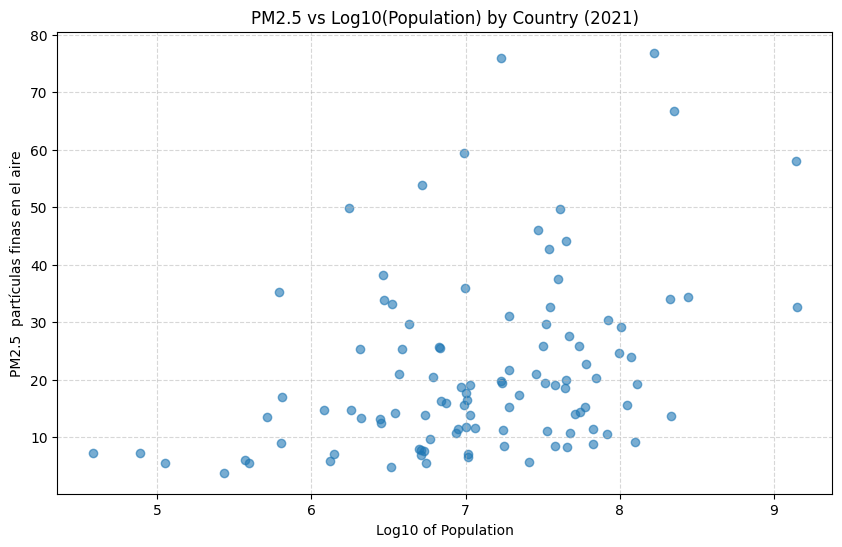

In [118]:
import matplotlib.pyplot as plt
import numpy as np

# Prepare data
plot_df = df_final.dropna(subset=["Population_WB", "PM25"]).copy()
plot_df["log_population"] = np.log10(plot_df["Population_WB"])

plt.figure(figsize=(10, 6))
plt.scatter(plot_df["log_population"], plot_df["PM25"], alpha=0.6)
plt.title("PM2.5 vs Log10(Population) by Country (2021)")
plt.xlabel("Log10 of Population")
plt.ylabel("PM2.5  partículas finas en el aire")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

El gráfico de dispersión, que compara los niveles de PM2.5 con el logaritmo del tamaño de la población, muestra que no existe una relación lineal fuerte entre la población de un país y sus niveles de contaminación del aire. Aunque algunos países con poblaciones muy elevadas presentan valores altos de PM2.5, otros no siguen este mismo patrón, lo que sugiere que el tamaño de la población por sí solo no es un factor determinante en los niveles de contaminación del aire.

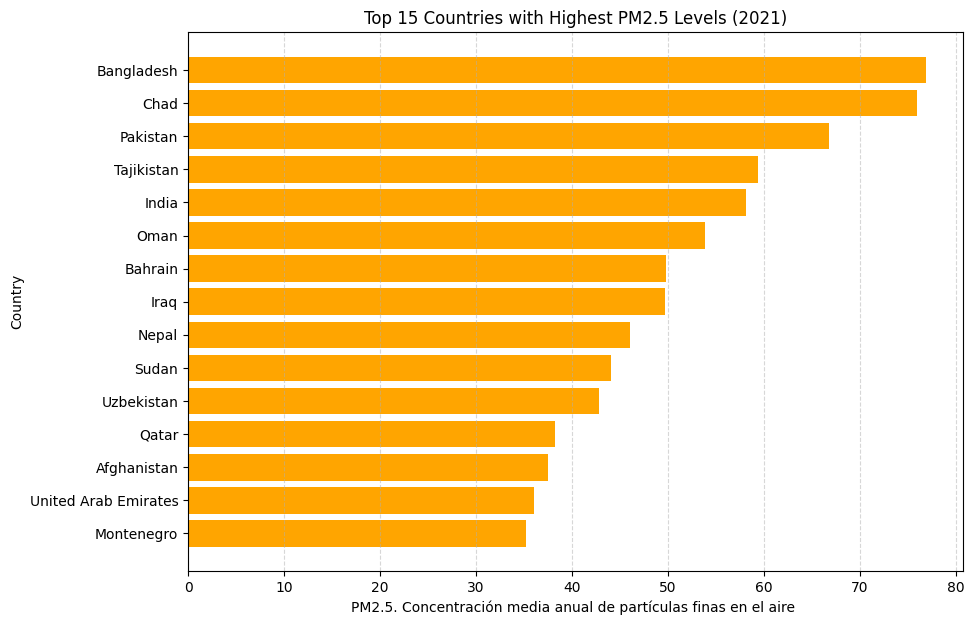

In [119]:
# Top 15 countries with highest PM2.5
top15 = plot_df.sort_values("PM25", ascending=False).head(15)

plt.figure(figsize=(10, 7))
plt.barh(top15["Country"], top15["PM25"], color="orange")
plt.gca().invert_yaxis()
plt.title("Top 15 Countries with Highest PM2.5 Levels (2021)")
plt.xlabel("PM2.5. Concentración media anual de partículas finas en el aire ")
plt.ylabel("Country")
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.show()

El gráfico de barras pone de manifiesto que los países con los niveles más elevados de PM2.5 en 2021 no son necesariamente los más poblados. Este resultado indica que factores adicionales, como la actividad industrial, las fuentes de energía utilizadas, las políticas y regulaciones medioambientales y el grado de urbanización, desempeñan un papel significativo en los niveles de contaminación del aire, más allá del tamaño de la población.

### 5.2 Reflexión
Si se dispusiera de más tiempo para completar el proyecto, se podrían abordar con mayor profundidad algunos aspectos relacionados con la calidad y la estructura de los datos, como la estandarización de los nombres de países para mejorar la tasa de coincidencia entre conjuntos de datos. Asimismo, sería interesante ampliar el análisis a múltiples años para estudiar la evolución temporal de la contaminación del aire. Por último, se podrían incorporar nuevas variables explicativas, como el PIB per cápita, el grado de urbanización o el uso de energías renovables, con el fin de explorar qué factores influyen con mayor peso en los niveles de PM2.5 a nivel mundial.

El análisis podría ampliarse incorporando variables adicionales como el PIB per cápita, la tasa de urbanización o el uso de energías renovables, con el fin de explicar mejor las diferencias en los niveles de contaminación del aire entre países. Asimismo, un análisis que abarcase múltiples años permitiría identificar tendencias a lo largo del tiempo y reforzar las conclusiones sobre las relaciones a largo plazo entre el crecimiento poblacional y la calidad del aire.